# ML Systems Concepts: Training Data, Sampling, and Core Math/Stats
This notebook is a **reference + mini-lab** covering foundational ML concepts with **small runnable demos** and **simple diagrams**.

**How to use**
- Skim the definitions
- Run the diagram cells
- Play with the parameters in the demos

> Tip: In Colab, use *Runtime → Run all* to generate all diagrams.


## 0) Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(7)

## 1) Big picture: where sampling and training data fit
In production ML, the **real world is not finite or stationary**. We create **training data** by sampling from a changing stream.

**Key idea**: Sampling is a *design choice* that shapes what your model can learn.


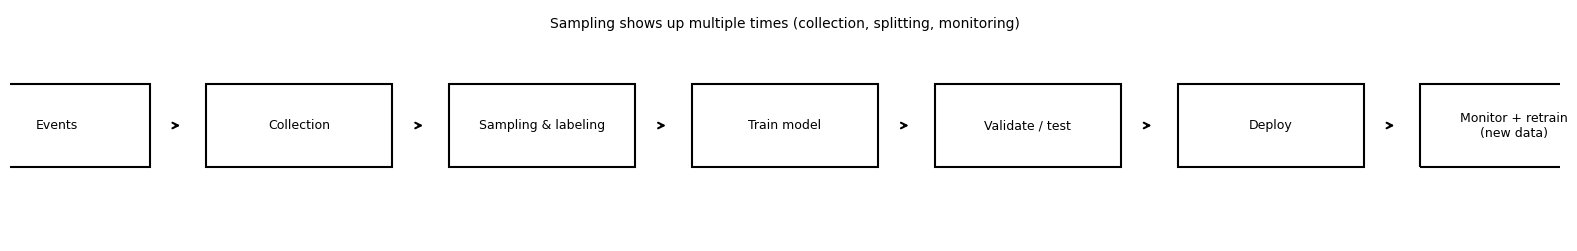

In [ ]:
# Diagram: ML lifecycle + sampling touchpoints
fig, ax = plt.subplots(figsize=(20, 3))
ax.axis("off")

steps = [
    "Events",
    "Collection",
    "Sampling & labeling",
    "Train model",
    "Validate / test",
    "Deploy",
    "Monitor + retrain\n(new data)"
]

x = np.linspace(0.03, 0.97, len(steps))
y = 0.5

for i, (xi, s) in enumerate(zip(x, steps)):
    ax.add_patch(plt.Rectangle((xi-0.06, y-0.18), 0.12, 0.36, fill=False, linewidth=1.5))
    ax.text(xi, y, s, ha="center", va="center", fontsize=9)
    if i < len(steps)-1:
        ax.annotate("", xy=(x[i+1]-0.075, y), xytext=(xi+0.075, y),
                    arrowprops=dict(arrowstyle="->", linewidth=1.5))

ax.text(0.5, 0.92, "Sampling shows up multiple times (collection, splitting, monitoring)", ha="center", fontsize=10)
plt.show()

## 2) Quick glossary (top definitions)
These are the most-used terms in ML systems.

- **Model**: parameterized function mapping inputs → outputs
- **Features** \(X\): inputs
- **Labels** \(Y\): targets
- **Training**: fit parameters to minimize loss on training data
- **Inference**: run the trained model to make predictions
- **Loss** \(\ell(\hat{y},y)\): error measure
- **Metric** (accuracy, AUC, etc.): performance measure
- **Overfitting**: great on train, bad on new data
- **Underfitting**: bad everywhere
- **Distribution shift**: the world changes (inputs, labels, or relationship)


## 3) The stats frame: data-generating process
We model the world as a joint distribution \(P(X, Y)\). Training data is a **finite sample**.

- **Population / real world**: what you care about
- **Sample / training data**: what you actually collected

**Empirical risk** (what we optimize):
\[
\hat{R}(f) = \frac{1}{n}\sum_{i=1}^n \ell(f(x_i), y_i)
\]

**Expected risk** (what you care about):
\[
R(f) = \mathbb{E}_{(X,Y)\sim P_{real}}[\ell(f(X), Y)]
\]


## 4) Sampling from the world → training data
Sampling choices can cause **selection bias**: the sample distribution differs from the real distribution.

### Demo: selection bias via subgroup under-sampling
Imagine a classifier used for two user groups A and B. If B is under-sampled, the model may perform poorly for B.


#### What we’re trying to do
- Build a simple classifier on a **biased training sample** (Group B is under-sampled).
- Evaluate on the **true population** and compare accuracy for Group A vs Group B.

#### Expected output (what you should see)
- The training sample shows **much fewer** Group B rows than the population.
- Model performance is typically **worse for Group B** (the under-represented group).
- After we fix sampling (stratified sample), Group B performance should improve or at least become less imbalanced.


In [ ]:
# Create a synthetic population with two groups, different feature distributions
n_pop = 20000
group = np.random.choice(["A", "B"], size=n_pop, p=[0.7, 0.3])

# Feature x differs by group; label y depends on x similarly across groups
x = np.where(group=="A", np.random.normal(0.0, 1.0, n_pop), np.random.normal(1.2, 1.0, n_pop))
logits = -0.2 + 1.0 * x
p = 1/(1+np.exp(-logits))
y = (np.random.rand(n_pop) < p).astype(int)

pop = pd.DataFrame({"group": group, "x": x, "y": y})
pop.head()

,group,x,y
0,A,-0.315702,0
1,A,0.087927,0
2,A,0.404901,0
3,A,-0.291389,1
4,A,0.045197,1


In [ ]:
# Sample training data with *bias*: severely under-sample group B
train_A = pop[pop.group=="A"].sample(3000, random_state=1)
train_B = pop[pop.group=="B"].sample(200,  random_state=1)  # under-sampled
train = pd.concat([train_A, train_B], ignore_index=True)

# Show group proportions
pd.DataFrame({
    "population": pop["group"].value_counts(normalize=True),
    "train_sample": train["group"].value_counts(normalize=True)
})

,population,train_sample
group,,
A,0.6989,0.9375
B,0.3011,0.0625


In [ ]:
# Simple logistic regression from scratch (to keep notebook self-contained)
def fit_logreg(X, y, lr=0.1, steps=2000):
    w = np.zeros(X.shape[1])
    b = 0.0
    for _ in range(steps):
        z = X @ w + b
        p = 1/(1+np.exp(-z))
        grad_w = (X.T @ (p - y)) / len(y)
        grad_b = np.mean(p - y)
        w -= lr * grad_w
        b -= lr * grad_b
    return w, b

def predict_proba(X, w, b):
    z = X @ w + b
    return 1/(1+np.exp(-z))

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

# Train on biased sample
X_train = train[["x"]].to_numpy()
y_train = train["y"].to_numpy()
w, b = fit_logreg(X_train, y_train)

# Evaluate on true population, split by group
for g in ["A","B"]:
    df = pop[pop.group==g]
    probs = predict_proba(df[["x"]].to_numpy(), w, b)
    preds = (probs >= 0.5).astype(int)
    print(g, "accuracy:", round(accuracy(df["y"].to_numpy(), preds), 4), "n=", len(df))

A accuracy: 0.6721 n= 13978
B accuracy: 0.7406 n= 6022


**What you should notice**: accuracy may be noticeably worse for the under-sampled group B.

This is a simplified illustration of **selection bias** and **representation gaps**.


## 5) Stratified sampling (a basic fix)
One straightforward practice: ensure your training sample preserves important subgroup proportions.


In [ ]:
# Stratified sample: preserve group proportions approximately
train_strat = (pop.groupby("group", group_keys=False)
                  .apply(lambda d: d.sample(int(3200*len(d)/len(pop)), random_state=2)))
train_strat["group"].value_counts(normalize=True)

/tmp/ipython-input-4020295930.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: d.sample(int(3200*len(d)/len(pop)), random_state=2)))


,proportion
group,
A,0.698968
B,0.301032


In [ ]:
# Train again
X_train2 = train_strat[["x"]].to_numpy()
y_train2 = train_strat["y"].to_numpy()
w2, b2 = fit_logreg(X_train2, y_train2)

for g in ["A","B"]:
    df = pop[pop.group==g]
    probs = predict_proba(df[["x"]].to_numpy(), w2, b2)
    preds = (probs >= 0.5).astype(int)
    print(g, "accuracy:", round(accuracy(df["y"].to_numpy(), preds), 4), "n=", len(df))

A accuracy: 0.672 n= 13978
B accuracy: 0.7418 n= 6022


## 6) Train/Validation/Test splits are also sampling
Splitting data is a sampling decision. If you split incorrectly, you can get **leakage** or unrealistically good metrics.

### Diagram: recommended split patterns
- **Random split**: ok when IID roughly holds
- **Time-based split**: required when time/order matters (forecasting, evolving behavior)


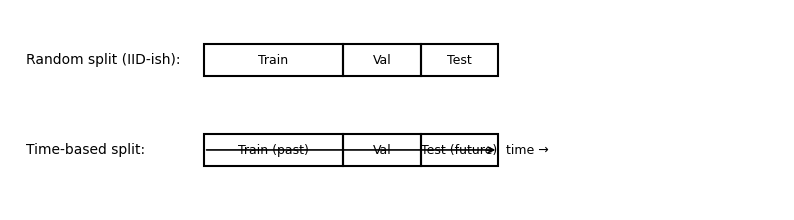

In [ ]:
fig, ax = plt.subplots(figsize=(10, 2.6))
ax.axis("off")

# Random split bar
ax.text(0.02, 0.75, "Random split (IID-ish):", fontsize=10, va="center")
ax.add_patch(plt.Rectangle((0.25, 0.67), 0.18, 0.16, fill=False, linewidth=1.5))
ax.text(0.34, 0.75, "Train", ha="center", va="center", fontsize=9)
ax.add_patch(plt.Rectangle((0.43, 0.67), 0.10, 0.16, fill=False, linewidth=1.5))
ax.text(0.48, 0.75, "Val", ha="center", va="center", fontsize=9)
ax.add_patch(plt.Rectangle((0.53, 0.67), 0.10, 0.16, fill=False, linewidth=1.5))
ax.text(0.58, 0.75, "Test", ha="center", va="center", fontsize=9)

# Time split bar
ax.text(0.02, 0.30, "Time-based split:", fontsize=10, va="center")
ax.add_patch(plt.Rectangle((0.25, 0.22), 0.18, 0.16, fill=False, linewidth=1.5))
ax.text(0.34, 0.30, "Train (past)", ha="center", va="center", fontsize=9)
ax.add_patch(plt.Rectangle((0.43, 0.22), 0.10, 0.16, fill=False, linewidth=1.5))
ax.text(0.48, 0.30, "Val", ha="center", va="center", fontsize=9)
ax.add_patch(plt.Rectangle((0.53, 0.22), 0.10, 0.16, fill=False, linewidth=1.5))
ax.text(0.58, 0.30, "Test (future)", ha="center", va="center", fontsize=9)

ax.annotate("", xy=(0.63, 0.30), xytext=(0.25, 0.30),
            arrowprops=dict(arrowstyle="->", linewidth=1.2))
ax.text(0.64, 0.30, "time →", fontsize=9, va="center")
plt.show()

## 7) Non-stationarity and distribution shifts
Production data changes over time.

- **Covariate shift**: \(P(X)\) changes
- **Label shift**: \(P(Y)\) changes
- **Concept drift**: \(P(Y\mid X)\) changes


#### What we’re trying to do
- Visualize a **covariate shift** where the input distribution changes from training to production.

#### Expected output
- Two overlapping histograms.
- The production histogram is shifted (different mean), illustrating `P(X)` changed.


**Key Characteristics**:  Input Distribution Change: The statistical properties (distribution) of the features (X) shift.

**Stable Relationship**: The conditional probability of the output given the input (\(P(Y|X)\)) remains constant.

**Example:** A loan default model trained on young applicants performs poorly when deployed to an older demographic, even if the factors predicting default for each group remain the same

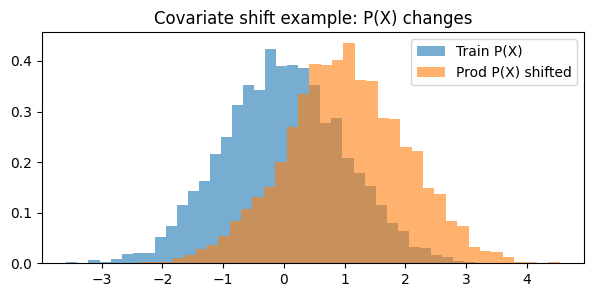

In [ ]:
# Diagram: covariate shift (feature distribution changes)
n = 5000
x_train = np.random.normal(0, 1, n)
x_prod  = np.random.normal(1.0, 1, n)  # shifted mean

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(x_train, bins=40, alpha=0.6, density=True, label="Train P(X)")
ax.hist(x_prod,  bins=40, alpha=0.6, density=True, label="Prod P(X) shifted")
ax.set_title("Covariate shift example: P(X) changes")
ax.legend()
plt.show()

**Solutions & Mitigation**

**Monitoring**: Continuously track input feature distributions using statistical tests or simpler models (detectors).

**Retraining**: Periodically retrain the model with fresh data that reflects the current distribution.

**Data Reweighting**: Adjust weights of training samples to better match the new distribution.

**Data Transformation:** Transform features to a more stable representation.

**Model Adaptation:** Employ techniques like domain adaptation or transfer learning.

## 8) Class imbalance and rare events
Many real problems have rare positives (fraud, abuse, defects). If you sample naively, the model can learn to predict the majority class.


#### What we’re trying to do
- Simulate a dataset where positives are **rare** (about 1%).
- Show that a trivial model that always predicts the majority class can achieve **high accuracy**.

#### Expected output
- You’ll see `Positive rate: ~0.01`.
- You’ll see `Accuracy of always-0 classifier: ~0.99`.
- This demonstrates why accuracy can be misleading; prefer precision/recall, PR-AUC, or cost-weighted metrics.


In [ ]:
# Imbalanced labels demo
n = 20000
X = np.random.normal(0, 1, (n, 1))
# Rare positive label (1%)
y = (np.random.rand(n) < 0.01).astype(int)

print("Positive rate:", y.mean())

# Trivial classifier always predicts 0
acc = (y == 0).mean()
print("Accuracy of always-0 classifier:", acc)

Positive rate: 0.01055
Accuracy of always-0 classifier: 0.98945


This shows why **accuracy can be misleading** under imbalance. Better metrics: precision/recall, PR-AUC, cost-weighted loss.


**Precision/Recall, PR-AUC, and cost-weighted loss** are essential tools for evaluating and training models on highly imbalanced datasets, where the positive class is rare.

They prioritize performance on the minority class by balancing accuracy, minimizing costly false positives (high precision), and maximizing detection (high recall)


**Cost-Weighted Loss (Training Optimization)**

**Purpose**: Addresses class imbalance during training by assigning higher penalties (costs) to misclassifying the minority class.

**Mechanism**: Instead of modifying the dataset, it modifies the loss function to force the algorithm to focus on rare instances, improving minority-class recall.

**Dynamic Weighting**: Techniques like focal loss or difficulty-based weighting can further prevent "precision collapse" by adapting focus throughout training.

## 9) Importance weighting (conceptual)
When your training sample distribution differs from the target distribution, you can correct (partially) by reweighting examples:

$$
w(x)=\frac{P_{\text{target}}(x)}{P_{\text{sample}}(x)}
$$

In practice, we estimate weights using density ratios, domain classifiers, or known sampling probabilities.


## 10) Bias–variance intuition (simple picture)
Increasing model complexity usually lowers bias and increases variance. More data reduces variance.


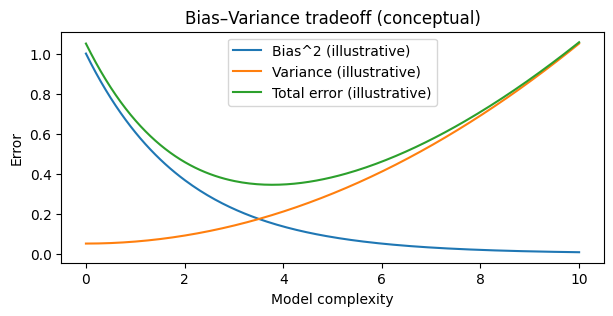

In [ ]:
# Toy bias-variance curve (illustrative, not from a specific model)
c = np.linspace(0, 10, 200)  # complexity
bias2 = np.exp(-c/2)         # decreases with complexity
var   = 0.05 + (c/10)**2     # increases with complexity
total = bias2 + var

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(c, bias2, label="Bias^2 (illustrative)")
ax.plot(c, var, label="Variance (illustrative)")
ax.plot(c, total, label="Total error (illustrative)")
ax.set_xlabel("Model complexity")
ax.set_ylabel("Error")
ax.set_title("Bias–Variance tradeoff (conceptual)")
ax.legend()
plt.show()

## 11) Monitoring: sampling in production
You often can’t log everything. Monitoring usually involves sampling:
- sample requests for detailed logging
- sample by cohort (region/device)
- sample failures more heavily

**Pitfall**: if you only sample “successful” events, you miss silent failures.


## 12) One-page concept map (appendix)
**Training data**: sampled + labeled subset of a changing world

**Sampling decisions** affect:
- representation (who/what is covered)
- evaluation validity (splits/leakage)
- robustness (rare events, OOD)
- monitoring sensitivity (what you can detect)

**Math anchors**: \(P(X,Y)\), \(P(X)\), \(P(Y)\), \(P(Y|X)\), empirical vs expected risk.


**https://www.deepchecks.com/f1-score-accuracy-roc-auc-and-pr-auc-metrics-for-models/**

![image.png](
  
)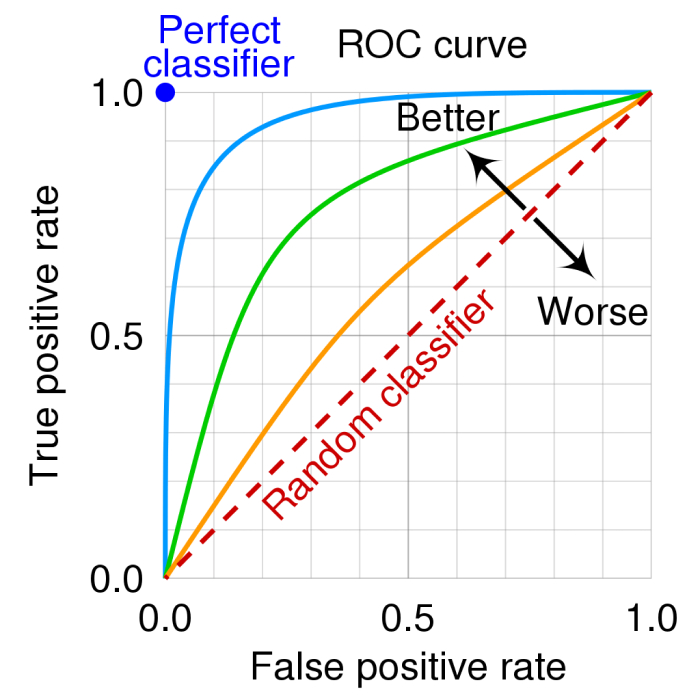

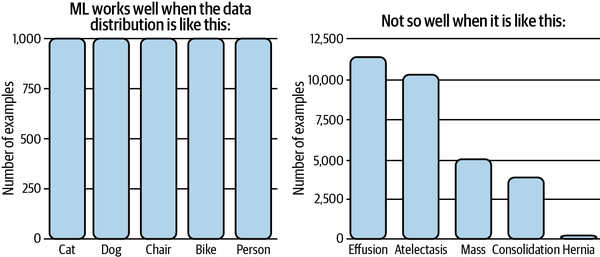